In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Reshape, Multiply,
    Add, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Mixed precision (faster GPU training, same accuracy) ──────
mixed_precision.set_global_policy('mixed_float16')

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [23]:
# ── Paths ─────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akilaibnath/cnn-braindata/Step2_Augmented_Dataset/train"
VALID_DIR = "/kaggle/input/datasets/akilaibnath/cnn-braindata/Step2_Augmented_Dataset/valid"
TEST_DIR  = "/kaggle/input/datasets/akilaibnath/cnn-braindata/Step2_Augmented_Dataset/test"

# ── Config ────────────────────────────────────────────────────
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32          # 64→32: smoother gradients, helps val loss stability
EPOCHS       = 150
WARMUP_EP    = 5           # linear LR warmup for first 5 epochs
BASE_LR      = 3e-4
MIN_LR       = 1e-6
NUM_CLASSES  = 4
LABEL_SMOOTH = 0.03
         
L2           = 1e-4        # L2 regularization weight

In [24]:
# ── Only rescale — dataset is pre-augmented ───────────────────
datagen = ImageDataGenerator(rescale=1./255)



train_gen = datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
valid_gen = datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print('Classes :', CLASS_NAMES)
print(f'Train   : {train_gen.samples}')
print(f'Valid   : {valid_gen.samples}')
print(f'Test    : {test_gen.samples}')

Found 26352 images belonging to 4 classes.
Found 1586 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train   : 26352
Valid   : 1586
Test    : 1584


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Building Blocks
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def se_block(inputs, ratio=16):
    """
    Squeeze-and-Excitation block.
    ratio=16 (was 8) — fewer params, similar performance.
    """
    filters = inputs.shape[-1]
    se = GlobalAveragePooling2D()(inputs)
    se = Dense(filters // ratio, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(L2))(se)
    se = Dense(filters, activation='sigmoid',
               kernel_regularizer=tf.keras.regularizers.l2(L2))(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([inputs, se])


def residual_block(x, filters, dropout_rate=0.0):
    """
    Pre-activation residual block (BN → ReLU → Conv).
    Better gradient flow than post-activation version.
    """
    shortcut = x

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same',
               kernel_regularizer=tf.keras.regularizers.l2(L2))(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    x = Conv2D(filters, 3, padding='same',
               kernel_regularizer=tf.keras.regularizers.l2(L2))(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same')(shortcut)
    return Add()([x, shortcut])


def multiscale_block(x, filters):
    """
    Inception-style multi-scale block.
    BN added after each branch for training stability.
    """
    def branch(inp, k):
        b = Conv2D(filters, k, padding='same',
                   kernel_regularizer=tf.keras.regularizers.l2(L2))(inp)
        b = BatchNormalization()(b)
        return Activation('relu')(b)

    return Concatenate()([branch(x, 1), branch(x, 3), branch(x, 5)])


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Full model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def build_msra_cnn(num_classes=4):
    inputs = Input(shape=(224, 224, 3))

    # Stem
    x = Conv2D(32, 3, padding='same',
               kernel_regularizer=tf.keras.regularizers.l2(L2))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)                      # 112×112×32

    # Block 1 — Residual + SE
    x = residual_block(x, 64, dropout_rate=0.1)
    x = se_block(x)
    x = MaxPooling2D()(x)                      # 56×56×64

    # Block 2 — Multiscale + SE
    x = multiscale_block(x, 64)
    x = se_block(x)
    x = MaxPooling2D()(x)                      # 28×28×192

    # Block 3 — Residual + SE
    x = residual_block(x, 128, dropout_rate=0.1)
    x = se_block(x)
    x = MaxPooling2D()(x)                      # 14×14×128

    # Block 4 — Multiscale + SE (256 filters)
    x = multiscale_block(x, 256)
    x = se_block(x)
    x = MaxPooling2D()(x)                      # 7×7×768

    # Block 5 — Residual + SE
    x = residual_block(x, 256, dropout_rate=0.15)
    x = se_block(x)                            # 7×7×256

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Dense head
    x = Dense(512, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(128, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    # float32 output (required with mixed_float16)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inputs, outputs, name='MSRA_CNN')


model = build_msra_cnn(NUM_CLASSES)
print('=' * 55)
model.summary()
print(f'\nTotal params: {model.count_params():,}')

Model: "MSRA_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 224, 224,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 112, 112,  │          0 │ activation_32[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ max_pooling2d_10… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 112, 112,  │     18,496 │ activation_33[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 112, 112,  │          0 │ activation_34[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 112, 112,  │     36,928 │ dropout_12[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 112, 112,  │      2,112 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 112, 112,  │          0 │ conv2d_34[0][0],  │
│                     │ 64)               │            │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_6[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │        320 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,700,124 (17.93 MB)

 Trainable params: 4,693,468 (17.90 MB)

 Non-trainable params: 6,656 (26.00 KB)


Total params: 4,700,124


In [26]:
class WarmupCosineDecay(tf.keras.callbacks.Callback):
    def __init__(self, total_epochs, warmup_epochs, base_lr, min_lr):
        super().__init__()
        self.total_epochs  = total_epochs
        self.warmup_epochs = warmup_epochs
        self.base_lr       = base_lr
        self.min_lr        = min_lr

    def _get_lr(self, epoch):
        if epoch < self.warmup_epochs:
            return self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (
                        self.total_epochs - self.warmup_epochs)
            cosine   = 0.5 * (1.0 + np.cos(np.pi * progress))
            return self.min_lr + (self.base_lr - self.min_lr) * cosine

    def _set_lr(self, lr):
        opt = self.model.optimizer
        if hasattr(opt, 'inner_optimizer'):   # unwrap LossScaleOptimizer
            opt = opt.inner_optimizer
        if hasattr(opt, 'learning_rate'):
            opt.learning_rate.assign(lr)
        elif hasattr(opt, 'lr'):
            tf.keras.backend.set_value(opt.lr, lr)

    def on_epoch_begin(self, epoch, logs=None):
        self._set_lr(float(self._get_lr(epoch)))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = float(self._get_lr(epoch))


# ── Compile ───────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BASE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTH
    ),
    metrics=['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────
callbacks = [
    WarmupCosineDecay(EPOCHS, WARMUP_EP, BASE_LR, MIN_LR),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=17,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_msra_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger('training_log.csv')
]

print('Compile done. Callbacks ready.')

Compile done. Callbacks ready.


In [27]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5732 - loss: 1.3569
Epoch 1: val_accuracy improved from None to 0.59521, saving model to best_msra_cnn.keras

Epoch 1: finished saving model to best_msra_cnn.keras
824/824 ━━━━━━━━━━━━━━━━━━━━ 168s 154ms/step - accuracy: 0.6661 - loss: 1.1787 - val_accuracy: 0.5952 - val_loss: 1.3063 - lr: 6.0000e-05
Epoch 2/150
824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7929 - loss: 0.9162
Epoch 2: val_accuracy improved from 0.59521 to 0.78121, saving model to best_msra_cnn.keras

Epoch 2: finished saving model to best_msra_cnn.keras
824/824 ━━━━━━━━━━━━━━━━━━━━ 93s 113ms/step - accuracy: 0.8155 - loss: 0.8670 - val_accuracy: 0.7812 - val_loss: 0.9120 - lr: 1.2000e-04
Epoch 3/150
824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8669 - loss: 0.7485
Epoch 3: val_accuracy did not improve from 0.78121
824/824 ━━━━━━━━━━━━━━━━━━━━ 90s 109ms/step - accuracy: 0.8854 - loss: 0.7080 - val_accuracy: 0.6362 - val_loss: 1.30

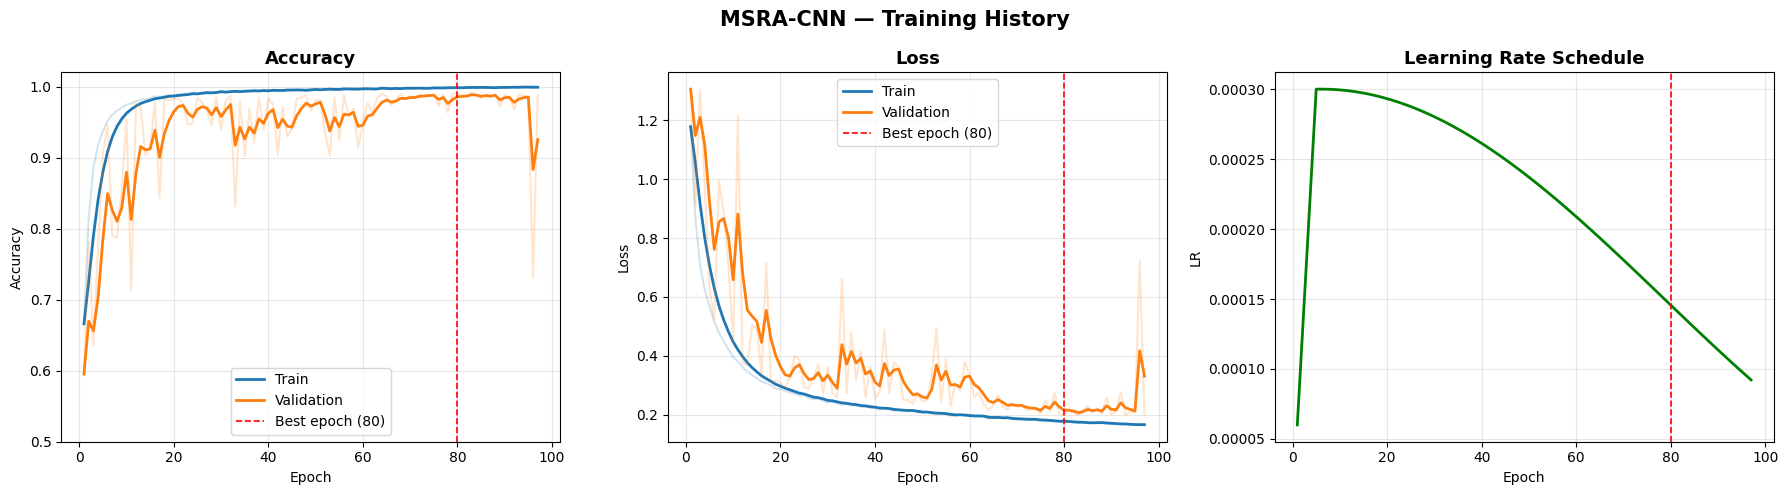

Best Epoch    : 80
Best Val Acc  : 0.9912
Best Val Loss : 0.1975


In [28]:
def ema_smooth(values, weight=0.6):
    """Exponential moving average smoothing."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed


ep          = range(1, len(history.history['accuracy']) + 1)
best_ep     = np.argmax(history.history['val_accuracy']) + 1
best_val_acc= max(history.history['val_accuracy'])
best_val_loss=min(history.history['val_loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
TC, VC = '#1f77b4', '#ff7f0e'

# ── Accuracy ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(ep, history.history['accuracy'],     color=TC, alpha=0.2)
ax.plot(ep, ema_smooth(history.history['accuracy']),
        color=TC, lw=2, label='Train')
ax.plot(ep, history.history['val_accuracy'], color=VC, alpha=0.2)
ax.plot(ep, ema_smooth(history.history['val_accuracy']),
        color=VC, lw=2, label='Validation')
ax.axvline(best_ep, color='red', ls='--', lw=1.2,
           label=f'Best epoch ({best_ep})')
ax.set_title('Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim([0.5, 1.02]); ax.legend(); ax.grid(alpha=0.3)

# ── Loss ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(ep, history.history['loss'],     color=TC, alpha=0.2)
ax.plot(ep, ema_smooth(history.history['loss']),
        color=TC, lw=2, label='Train')
ax.plot(ep, history.history['val_loss'], color=VC, alpha=0.2)
ax.plot(ep, ema_smooth(history.history['val_loss']),
        color=VC, lw=2, label='Validation')
ax.axvline(best_ep, color='red', ls='--', lw=1.2,
           label=f'Best epoch ({best_ep})')
ax.set_title('Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── LR Schedule ───────────────────────────────────────────────
ax  = axes[2]
lrs = []
for e in range(len(history.history['accuracy'])):
    if e < WARMUP_EP:
        lrs.append(BASE_LR * (e + 1) / WARMUP_EP)
    else:
        prog = (e - WARMUP_EP) / (EPOCHS - WARMUP_EP)
        lrs.append(MIN_LR + (BASE_LR - MIN_LR) * 0.5 *
                   (1 + np.cos(np.pi * prog)))
ax.plot(ep, lrs, color='green', lw=2)
ax.axvline(best_ep, color='red', ls='--', lw=1.2)
ax.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.grid(alpha=0.3)

plt.suptitle('MSRA-CNN — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Best Epoch    : {best_ep}')
print(f'Best Val Acc  : {best_val_acc:.4f}')
print(f'Best Val Loss : {best_val_loss:.4f}')

In [29]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc:.4f}')

y_pred_prob    = model.predict(test_gen, verbose=0)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true         = test_gen.classes

Test Loss : 0.1891
Test Acc  : 0.9931


In [30]:
def compute_metrics(y_true, y_pred, label=''):
    acc   = accuracy_score(y_true, y_pred)
    pre   = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1    = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc   = matthews_corrcoef(y_true, y_pred)

    print(f'\n── {label} ───────────────────────────')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Precision       : {pre:.4f}')
    print(f'  Recall          : {rec:.4f}')
    print(f'  F1 Score        : {f1:.4f}')
    print(f'  Cohen Kappa (κ) : {kappa:.4f}')
    print(f'  MCC             : {mcc:.4f}')
    return dict(Accuracy=acc, Precision=pre, Recall=rec,
                F1=f1, Kappa=kappa, MCC=mcc)


m_std = compute_metrics(y_true, y_pred_classes, 'Standard Prediction')


print('\n── Per-class Report ──────────────────────')
print(classification_report(
    y_true, y_pred_classes, target_names=CLASS_NAMES
))


── Standard Prediction ───────────────────────────
  Accuracy        : 0.9931
  Precision       : 0.9931
  Recall          : 0.9931
  F1 Score        : 0.9931
  Cohen Kappa (κ) : 0.9905
  MCC             : 0.9905

── Per-class Report ──────────────────────
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       563
  meningioma       0.98      0.99      0.99       351
    no_tumor       0.99      1.00      1.00       264
   pituitary       1.00      0.99      1.00       406

    accuracy                           0.99      1584
   macro avg       0.99      0.99      0.99      1584
weighted avg       0.99      0.99      0.99      1584



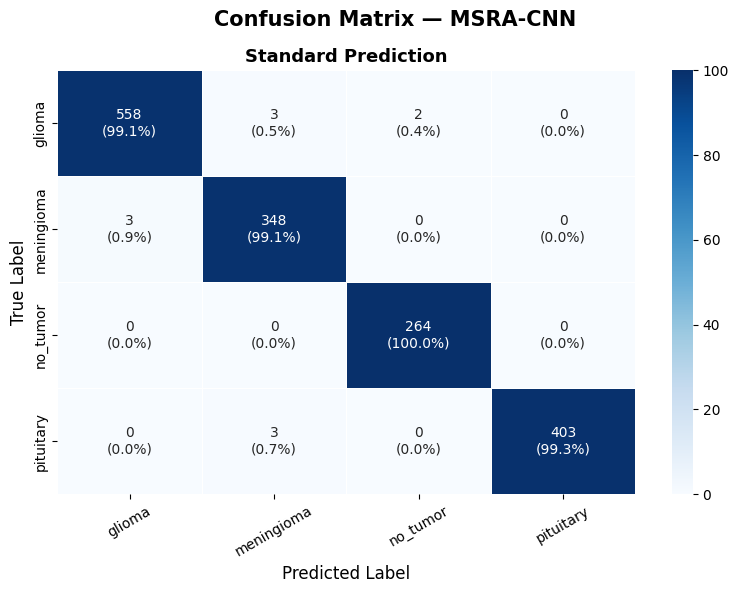

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

cm     = confusion_matrix(y_true, y_pred_classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annot = np.array([
    [f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
     for j in range(len(CLASS_NAMES))]
    for i in range(len(CLASS_NAMES))
])

sns.heatmap(
    cm_pct, annot=annot, fmt='', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, vmin=0, vmax=100,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Standard Prediction', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix — MSRA-CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

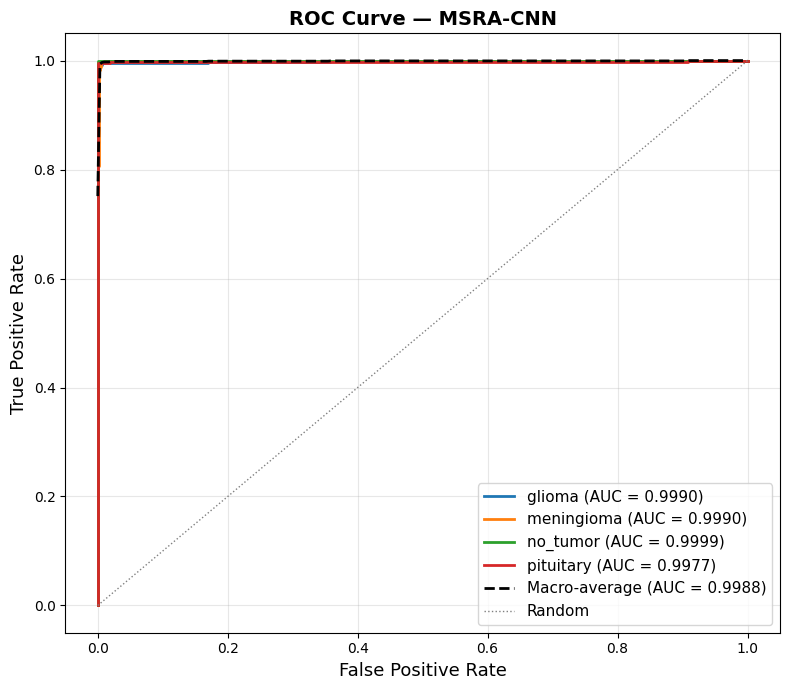

Per-class AUC : {'glioma': '0.9990', 'meningioma': '0.9990', 'no_tumor': '0.9999', 'pituitary': '0.9977'}
Macro AUC     : 0.9988


In [32]:
n_classes = len(CLASS_NAMES)
y_bin     = label_binarize(y_true, classes=list(range(n_classes)))
colors    = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

mean_fpr = np.linspace(0, 1, 300)
tprs, roc_aucs = [], []

fig, ax = plt.subplots(figsize=(8, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    roc_aucs.append(roc_auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.4f})')

# Macro-average
mean_tpr     = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
macro_auc    = auc(mean_fpr, mean_tpr)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2,
        label=f'Macro-average (AUC = {macro_auc:.4f})')
ax.plot([0,1],[0,1], color='gray', lw=1, ls=':', label='Random')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC Curve — MSRA-CNN', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('Per-class AUC :', {c: f'{a:.4f}' for c, a in zip(CLASS_NAMES, roc_aucs)})
print(f'Macro AUC     : {macro_auc:.4f}')

In [33]:
for layer in model.layers:
    print(layer.name)

input_layer_2
conv2d_32
batch_normalization_32
activation_32
max_pooling2d_10
batch_normalization_33
activation_33
conv2d_33
batch_normalization_34
activation_34
dropout_12
conv2d_34
conv2d_35
add_6
global_average_pooling2d_12
dense_28
dense_29
reshape_10
multiply_10
max_pooling2d_11
conv2d_36
conv2d_37
conv2d_38
batch_normalization_35
batch_normalization_36
batch_normalization_37
activation_35
activation_36
activation_37
concatenate_4
global_average_pooling2d_13
dense_30
dense_31
reshape_11
multiply_11
max_pooling2d_12
batch_normalization_38
activation_38
conv2d_39
batch_normalization_39
activation_39
dropout_13
conv2d_40
conv2d_41
add_7
global_average_pooling2d_14
dense_32
dense_33
reshape_12
multiply_12
max_pooling2d_13
conv2d_42
conv2d_43
conv2d_44
batch_normalization_40
batch_normalization_41
batch_normalization_42
activation_40
activation_41
activation_42
concatenate_5
global_average_pooling2d_15
dense_34
dense_35
reshape_13
multiply_13
max_pooling2d_14
batch_normalization_43
act

Predicted Class : meningioma
Confidence      : 98.03 %


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_210']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


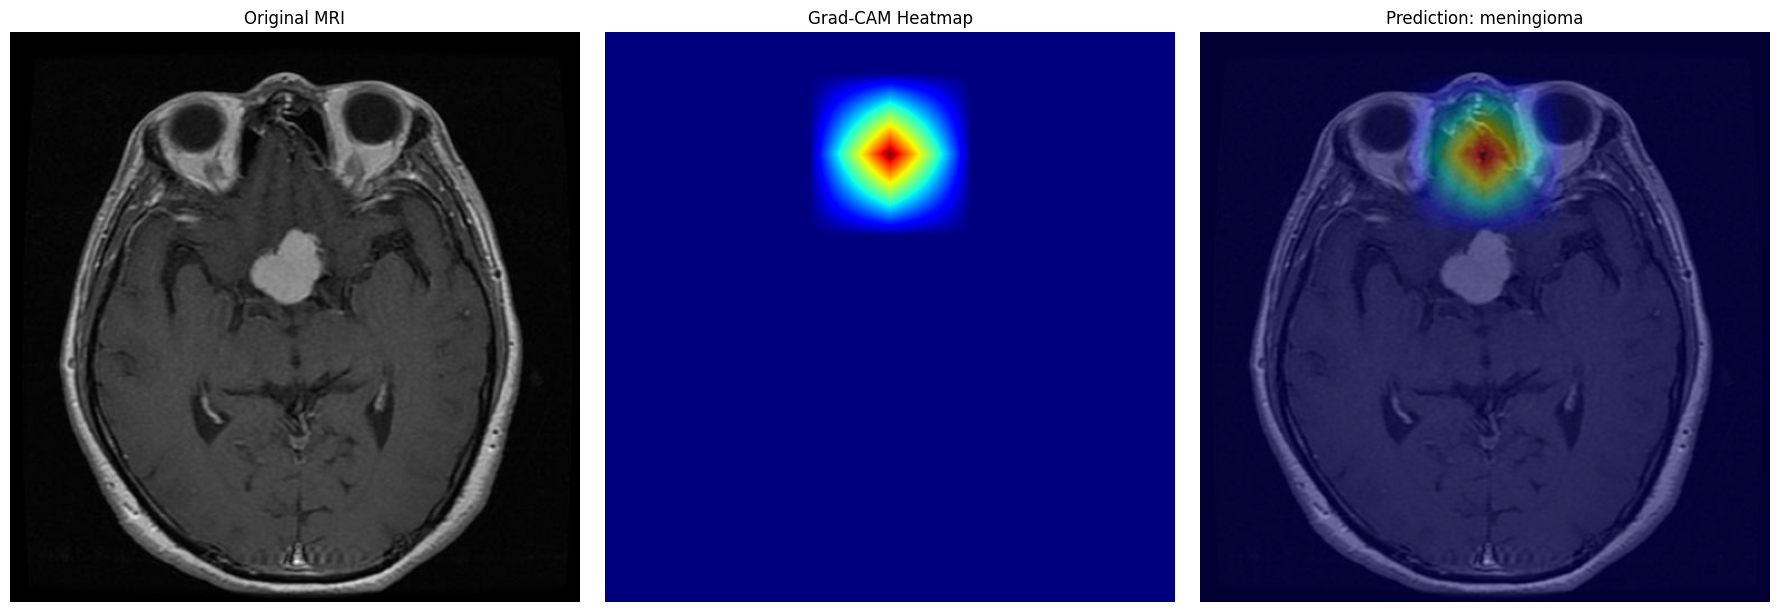

In [36]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ====================================================
# IMAGE PATH
# ====================================================

IMG_PATH = "/kaggle/input/datasets/akilaibnath/cnn-braindata/Step2_Augmented_Dataset/test/meningioma/meningioma1019.jpg"

# ====================================================
# SETTINGS
# ====================================================

LAST_CONV_LAYER = "conv2d_47"

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

# ====================================================
# LOAD IMAGE
# ====================================================

img = tf.keras.preprocessing.image.load_img(
    IMG_PATH,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ====================================================
# PREDICTION
# ====================================================

preds = model.predict(img_array, verbose=0)

pred_class = np.argmax(preds[0])

print("Predicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(np.max(preds[0])*100,2), "%")

# ====================================================
# GRAD MODEL
# ====================================================

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(LAST_CONV_LAYER).output,
        model.output
    ]
)

# ====================================================
# COMPUTE GRAD-CAM
# ====================================================

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, pred_class]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(heatmap, 0)

max_heat = tf.reduce_max(heatmap)

if max_heat > 0:
    heatmap = heatmap / max_heat

heatmap = heatmap.numpy()

# ====================================================
# LOAD ORIGINAL IMAGE
# ====================================================

original = cv2.imread(IMG_PATH)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# ====================================================
# RESIZE HEATMAP
# ====================================================

heatmap = cv2.resize(
    heatmap.astype(np.float32),
    (original.shape[1], original.shape[0])
)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# ====================================================
# OVERLAY
# ====================================================

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ====================================================
# DISPLAY
# ====================================================

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title(
    f"Prediction: {CLASS_NAMES[pred_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
print("Original Shape:", original.shape)
print("Heatmap Shape :", heatmap.shape)
print("Heatmap Type  :", heatmap.dtype)

Original Shape: (512, 512, 3)
Heatmap Shape : (7, 7)
Heatmap Type  : float16


Predicted Class : glioma
Confidence      : 97.96 %


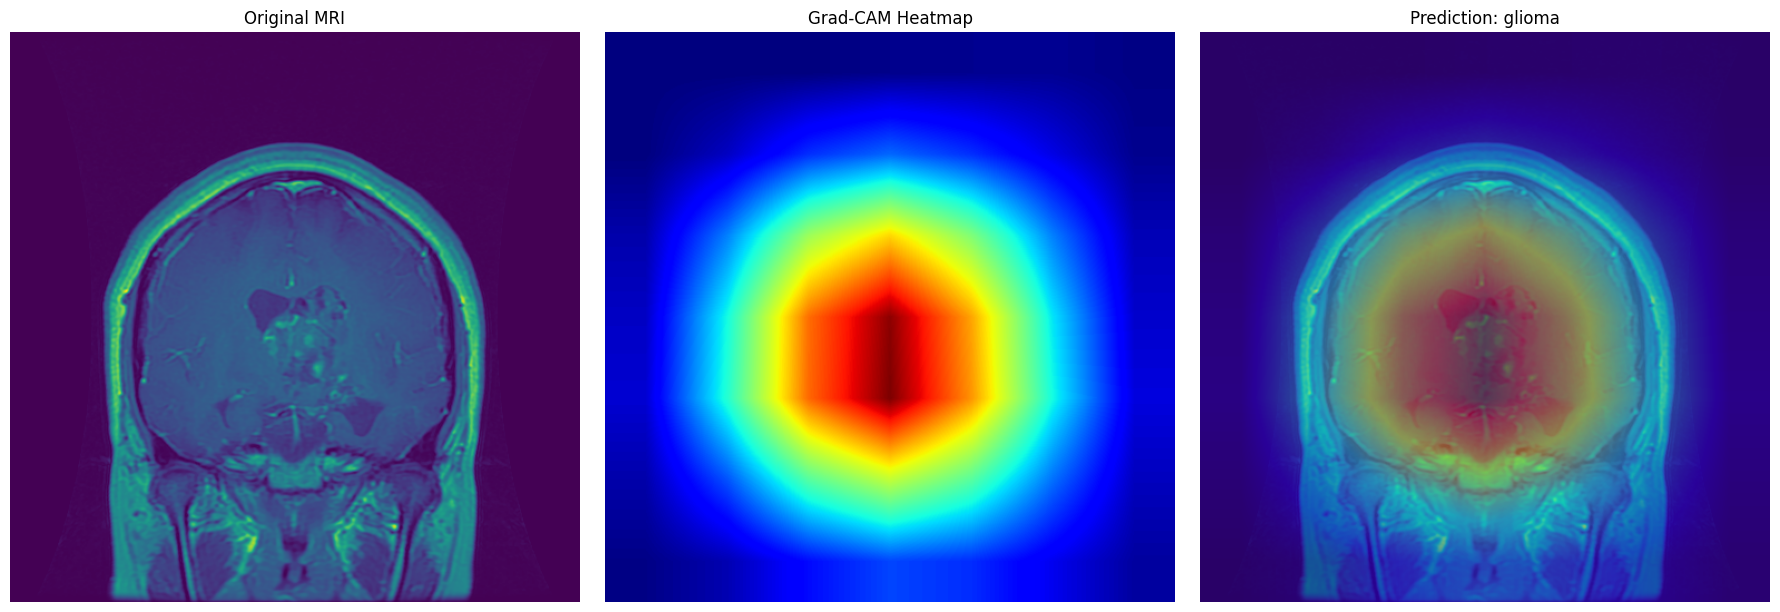

In [41]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ==========================================
# IMAGE PATH
# ==========================================

IMG_PATH = "/kaggle/input/datasets/akilaibnath/cnn-braindata/Step2_Augmented_Dataset/test/glioma/glioma1046.png"

# ==========================================
# SETTINGS
# ==========================================

LAST_CONV_LAYER = "conv2d_46"

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

# ==========================================
# LOAD IMAGE
# ==========================================

img = tf.keras.preprocessing.image.load_img(
    IMG_PATH,
    target_size=(224, 224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ==========================================
# PREDICTION
# ==========================================

preds = model.predict(img_array, verbose=0)

pred_class = np.argmax(preds[0])

print("Predicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(np.max(preds[0]) * 100, 2), "%")

# ==========================================
# GRAD-CAM MODEL
# ==========================================

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        model.get_layer(LAST_CONV_LAYER).output,
        model.output
    ]
)

# ==========================================
# COMPUTE GRAD-CAM
# ==========================================

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, pred_class]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(heatmap, 0)

if tf.reduce_max(heatmap) > 0:
    heatmap = heatmap / tf.reduce_max(heatmap)

# ==========================================
# CONVERT TO NUMPY + FLOAT32
# ==========================================

heatmap = heatmap.numpy()
heatmap = np.squeeze(heatmap)
heatmap = heatmap.astype(np.float32)

# ==========================================
# LOAD ORIGINAL IMAGE
# ==========================================

original = cv2.imread(IMG_PATH)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# ==========================================
# RESIZE HEATMAP
# ==========================================

heatmap = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# ==========================================
# OVERLAY
# ==========================================

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ==========================================
# DISPLAY
# ==========================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Prediction: {CLASS_NAMES[pred_class]}")
plt.axis("off")

plt.tight_layout()
plt.show()

Predicted Class : pituitary
Confidence      : 98.08 %


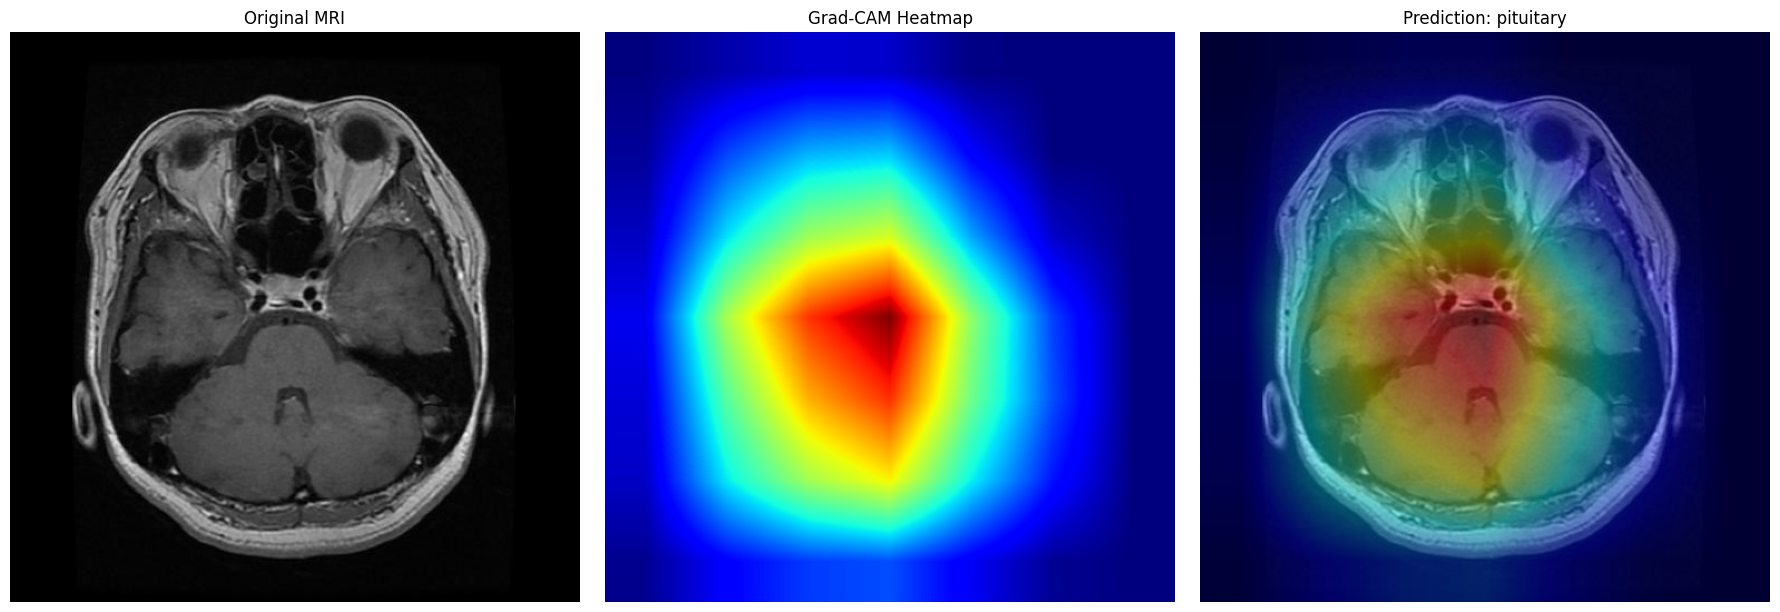

In [43]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ==========================================
# IMAGE PATH
# ==========================================

IMG_PATH = "/kaggle/input/datasets/akilaibnath/cnn-braindata/Step2_Augmented_Dataset/test/pituitary/pituitary1045.jpg"

# ==========================================
# SETTINGS
# ==========================================

LAST_CONV_LAYER = "conv2d_46"

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

# ==========================================
# LOAD IMAGE
# ==========================================

img = tf.keras.preprocessing.image.load_img(
    IMG_PATH,
    target_size=(224, 224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ==========================================
# PREDICTION
# ==========================================

preds = model.predict(img_array, verbose=0)

pred_class = np.argmax(preds[0])

print("Predicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(np.max(preds[0]) * 100, 2), "%")

# ==========================================
# GRAD-CAM MODEL
# ==========================================

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        model.get_layer(LAST_CONV_LAYER).output,
        model.output
    ]
)

# ==========================================
# COMPUTE GRAD-CAM
# ==========================================

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, pred_class]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(heatmap, 0)

if tf.reduce_max(heatmap) > 0:
    heatmap = heatmap / tf.reduce_max(heatmap)

# ==========================================
# CONVERT TO NUMPY + FLOAT32
# ==========================================

heatmap = heatmap.numpy()
heatmap = np.squeeze(heatmap)
heatmap = heatmap.astype(np.float32)

# ==========================================
# LOAD ORIGINAL IMAGE
# ==========================================

original = cv2.imread(IMG_PATH)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# ==========================================
# RESIZE HEATMAP
# ==========================================

heatmap = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# ==========================================
# OVERLAY
# ==========================================

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ==========================================
# DISPLAY
# ==========================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Prediction: {CLASS_NAMES[pred_class]}")
plt.axis("off")

plt.tight_layout()
plt.show()